In [43]:
import csv
import numpy as np
import matplotlib.pyplot as plt

In [44]:
# Opening the data file and reading it using csv.reader
file = open("ex1data1.csv")   # open the data file
fileObject = csv.reader(file) # wrap it in an object that knows how to parse CSV 

In [45]:
# Initializing X and Y as zero arrays of appropriate dimensions
m = 97 
n = 1 
X = np . zeros (( m ,  n )) #d
Y = np . zeros (( m ,  n ))

In [46]:
# Reading the data from the file and storing it in X and Y
index = 0 
for x,y in fileObject : 
    X [ index ]  = x  # X[i] = x⁽ⁱ⁾ 
    Y [ index ]  = y  # Y[i] = y⁽ⁱ⁾
    index = index + 1

Text(0, 0.5, 'Profit of a food truck in that city')

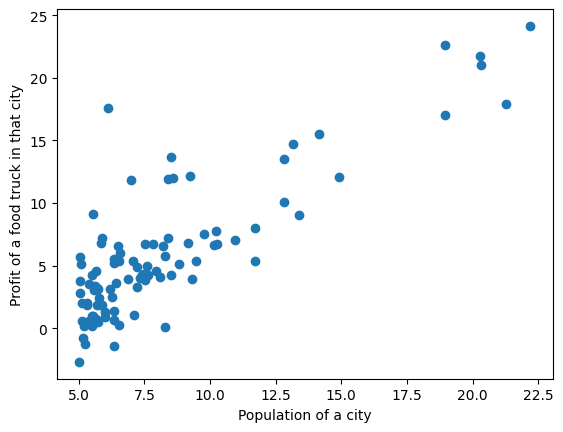

In [47]:
# Plotting the data points
plt.scatter(X,Y)
plt.xlabel("Population of a city")
plt.ylabel("Profit of a food truck in that city")

In [48]:
# Initializing w and b as zero
#   w_b = [ b ] = [ 0  ]    shape: (2 × 1), as we have only one feature which means n=1
#         [ w ]   [ 0 ]
w_b = np . zeros (( n + 1 ,  1 ))

In [49]:
# Adding a column of ones to X to account for the bias term b in the linear regression model
#   X = [ 1   x⁽¹⁾ ]   shape: (97 × 2)  
#       [ 1   x⁽²⁾ ]             
#       [ ⋮    ⋮   ]             
#       [ 1   x⁽ᵐ⁾ ] 
X = np . c_ [ np . ones ( m ),  X ]

In [50]:
# Defining the cost function J(w,b) for linear regression, which computes the mean squared error
#        1   m
#  J =  ─── Σ  ( ŷ⁽ⁱ⁾ - y⁽ⁱ⁾ )²
#       2m  i=1
def computeCost ( X ,  Y ,  w_b ):
    y_predicted = np.matmul(X,w_b)  # ŷ = Xw (matrix multiplication), dimension: (97,1)
    squaredError = np.square(np.subtract(y_predicted,Y)) #(ŷ⁽ⁱ⁾ - y⁽ⁱ⁾)² for all i,shape: (97 × 1)
    J = np.sum(squaredError)/(2*m) # performed Σ (sum) and divided by 2m
    return J    

In [51]:
#printing initial cost by calling cost function with w and b initialized as zero
print ("Initial Cost:",computeCost ( X ,  Y ,  w_b )) 

Initial Cost: 32.072733877455676


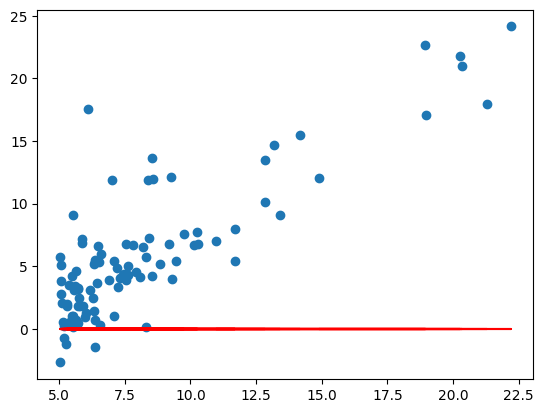

In [52]:
#Plotting the initial regression line with w and b initialized as zero
plt.scatter(X[:,1],Y) 
plt.plot(X[:,1],np.matmul(X,w_b),color='red')

In [53]:
# Implementing gradient descent to optimize w and b
alpha = 0.01
x_feature = X[:, 1] #x_feature has a shape (97,)
x_feature = x_feature.reshape(m, 1) # Now x_feature has dimension (97,1)
for i in range ( 20 ):
    error = np . matmul ( X , w_b ) - Y        # ŷ - y, error has dimension (97,1)
    dJ_db  = np.sum(error) / m              # ∂J/∂b = 1/m Σ (ŷ⁽ⁱ⁾ − y⁽ⁱ⁾), it is a scalar
    dJ_dw  = np.sum(error * x_feature) / m  # ∂J/∂w =  1/m Σ (ŷ⁽ⁱ⁾ − y⁽ⁱ⁾) · x⁽ⁱ⁾ , it is a scalar   
    w_b [ 0 ]  = w_b [ 0 ]  - alpha * dJ_db # b := b - α · ∂J/∂b
    w_b [ 1 ]  = w_b [ 1 ]  - alpha * dJ_dw # w := w - α · ∂J/∂w


Final values of b and w: [[-0.06116598]
 [ 0.80780498]]
Final cost (value of J) after running 1500 iterations: 5.815639648492154


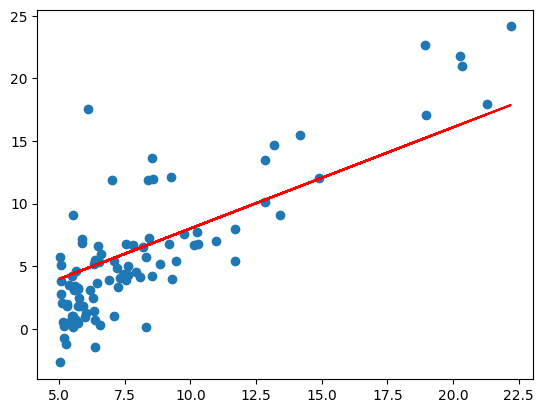

In [54]:
# After running gradient descent for 1500 iterations, we print the final status -
# The final values of w and b:
print ( "Final values of b and w:", w_b ) 

# plot the final regression line: 
plt.scatter ( X [:, 1 ],  Y )
plt.plot ( X [:, 1 ], np . matmul ( X , w_b ), color = 'red' )

# and compute the final cost:
print ("Final cost (value of J) after running 1500 iterations:",computeCost ( X ,  Y ,  w_b ))